<a href="https://colab.research.google.com/github/rizwinmk/ICT_DSA_NOTES/blob/main/supervised_CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exploratory Data Analysis (EDA)**

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df=pd.read_csv('Training_data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [3]:
df.shape

(5634, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


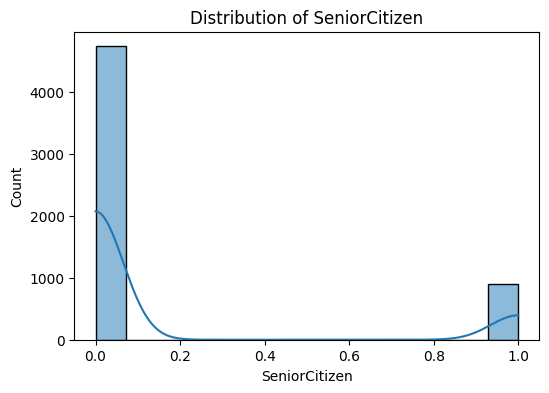

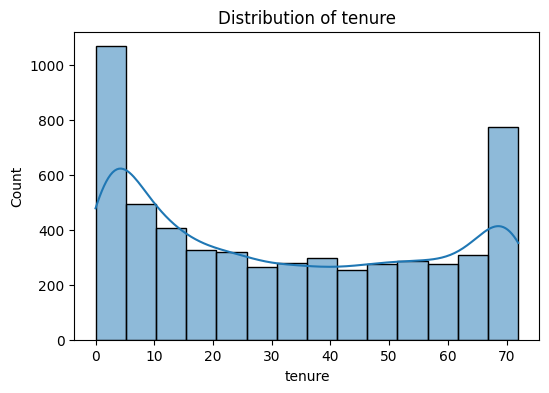

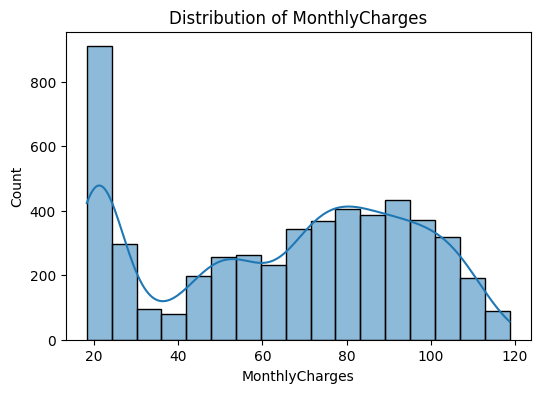

In [6]:
#distrbution of numerical features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

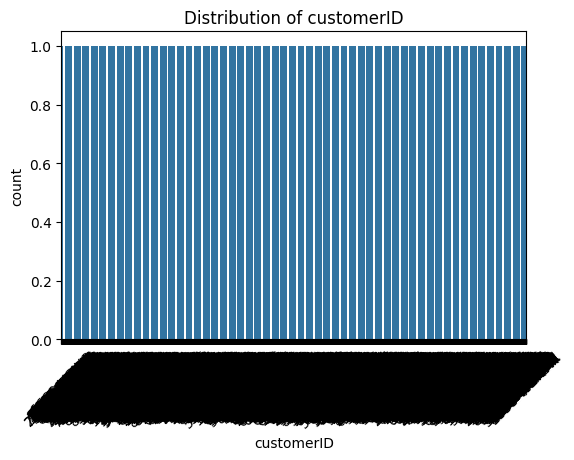

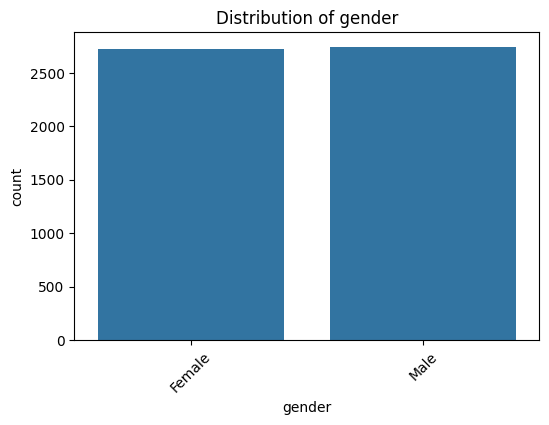

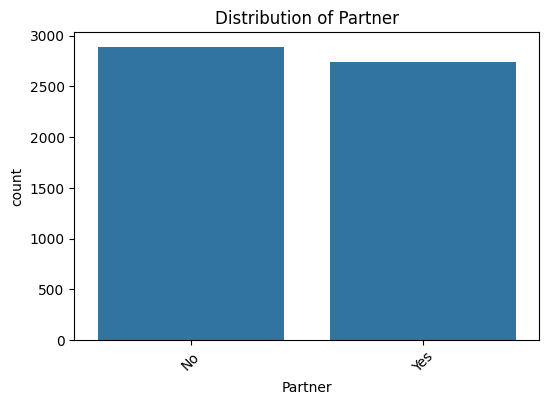

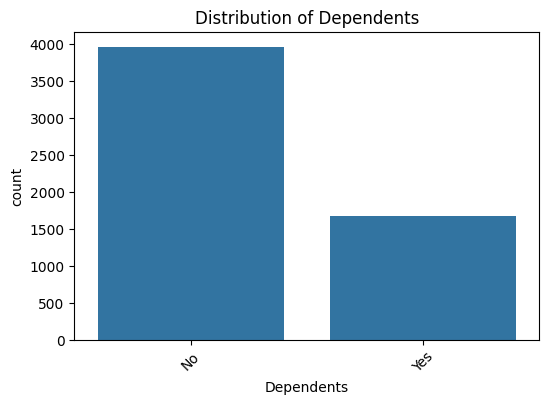

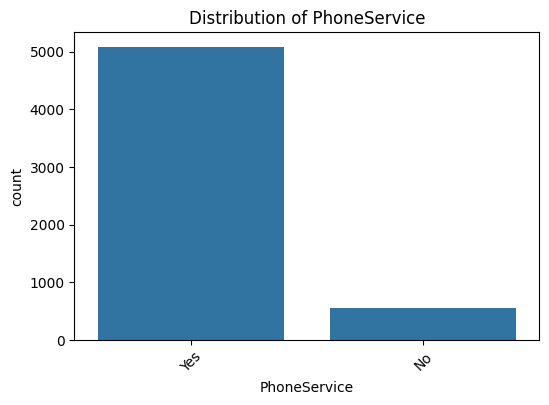

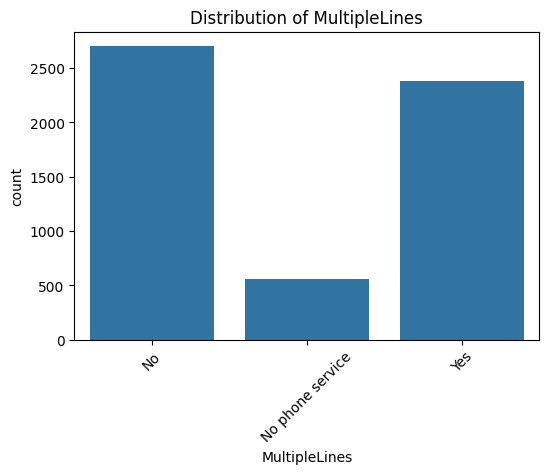

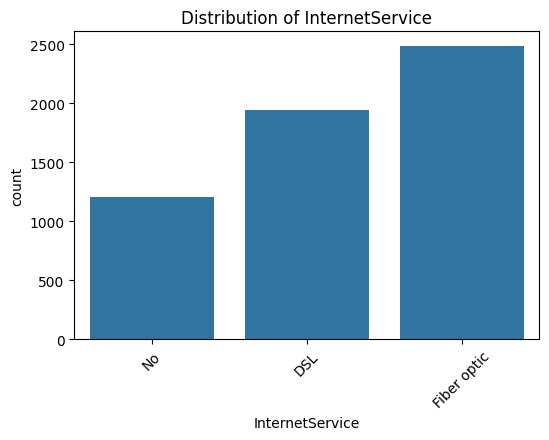

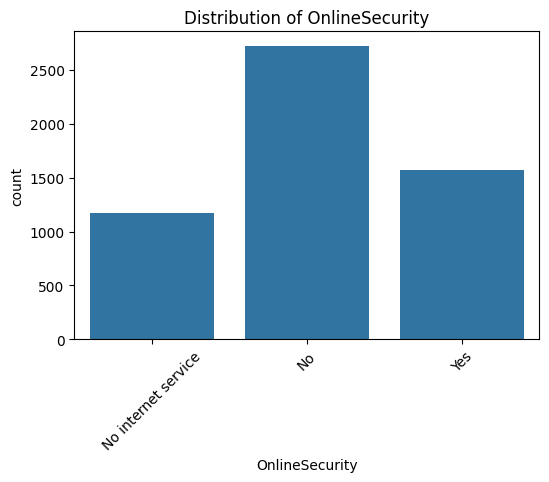

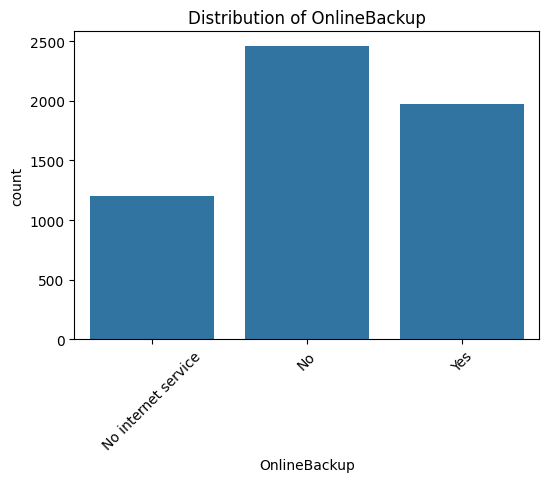

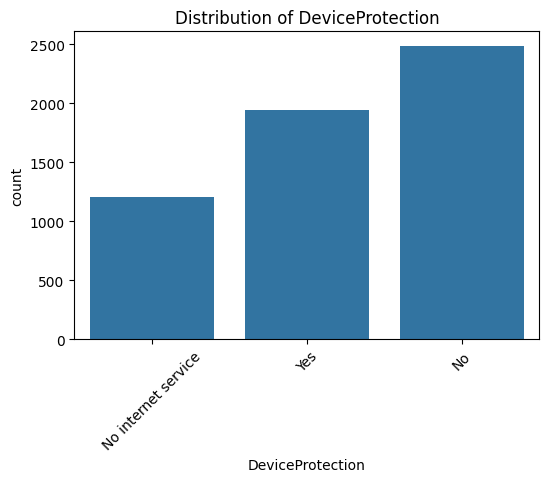

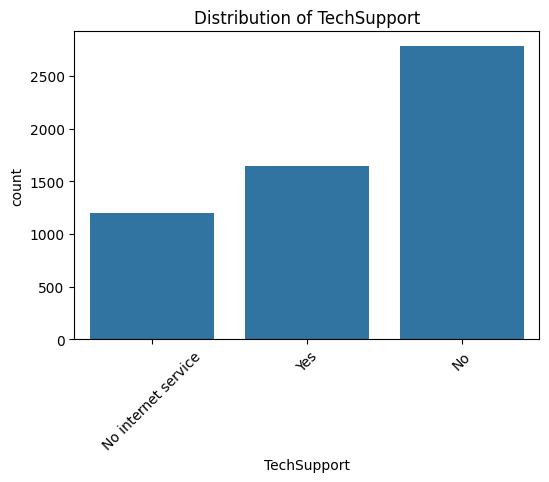

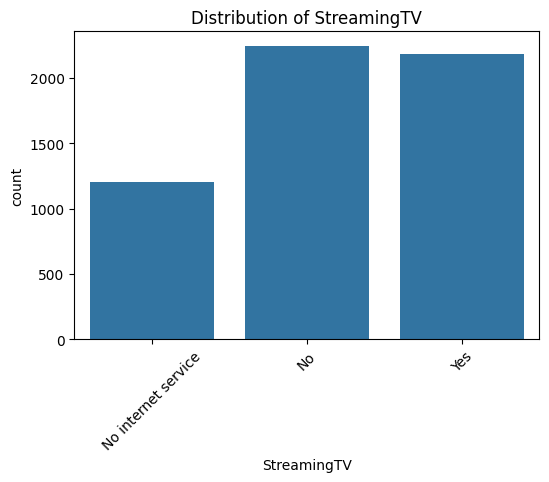

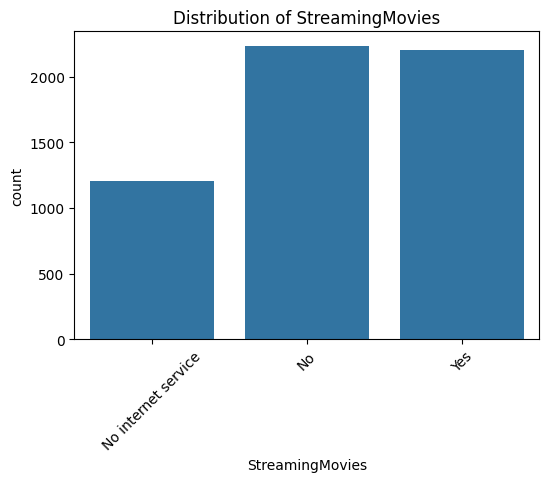

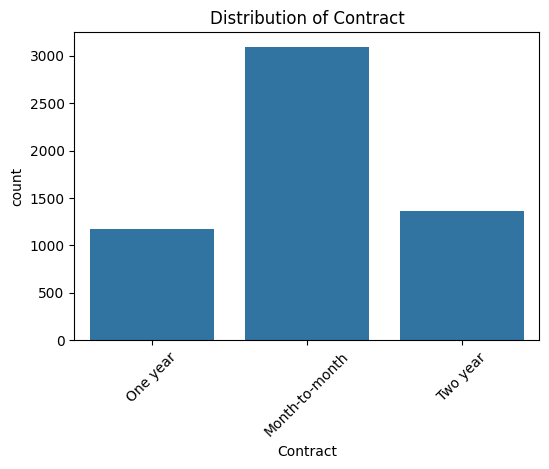

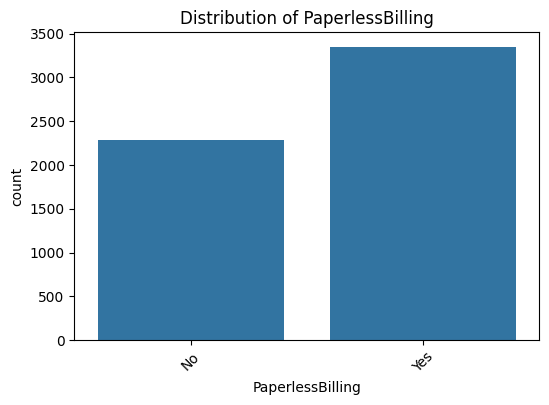

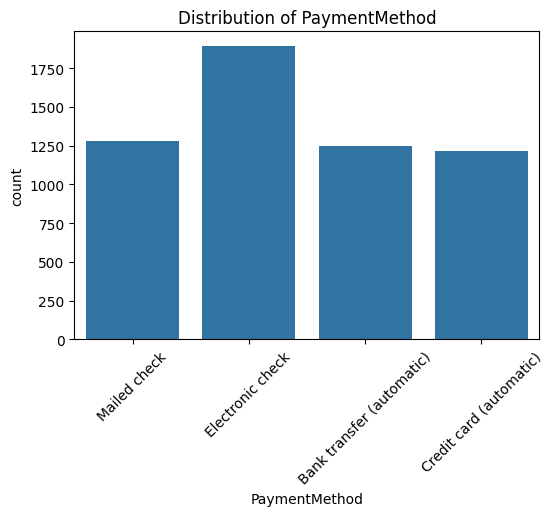

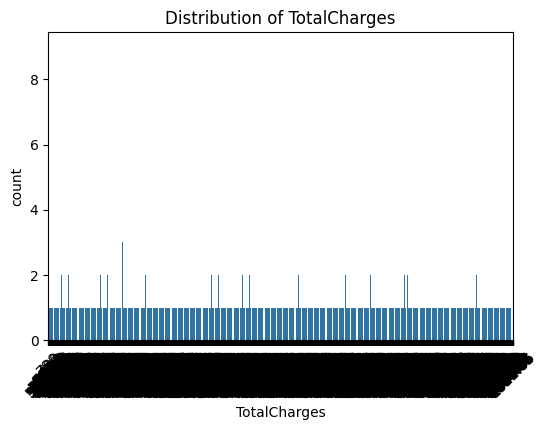

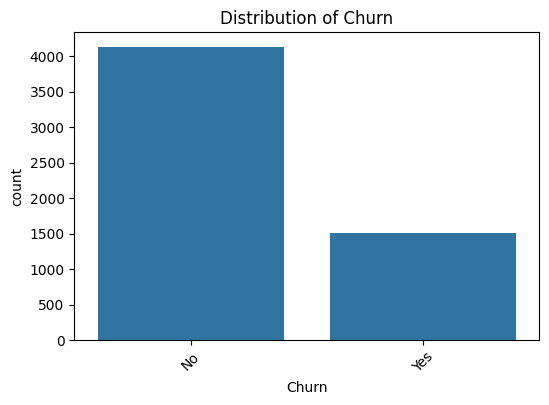

In [7]:

#distribution of categorical features
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')
    plt.show()

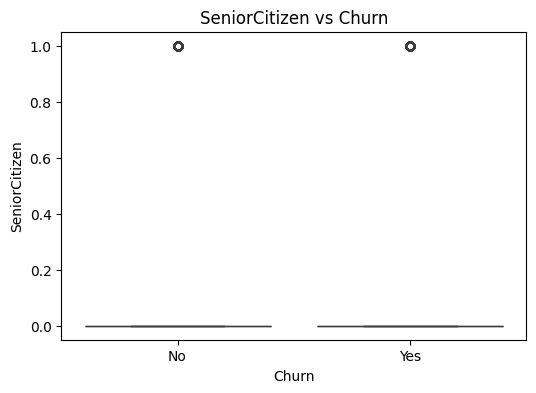

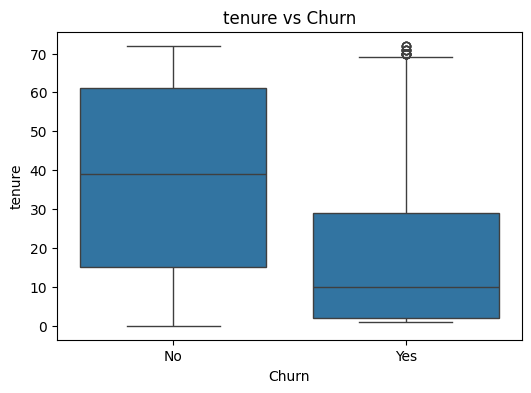

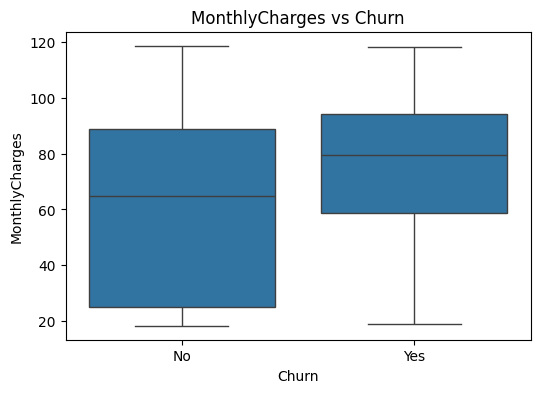

In [8]:
#relationship with churn numericla cols
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

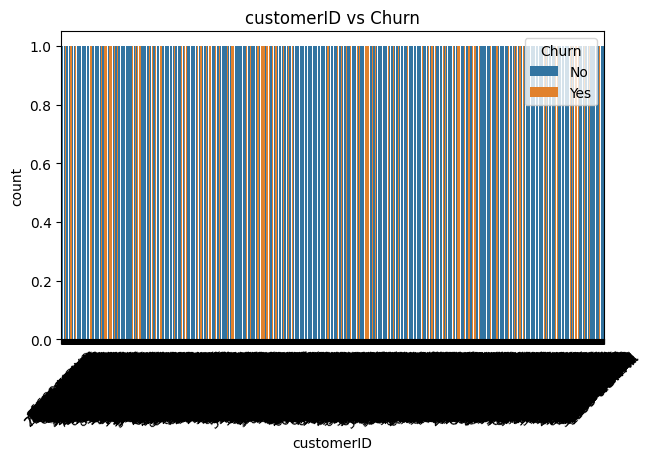

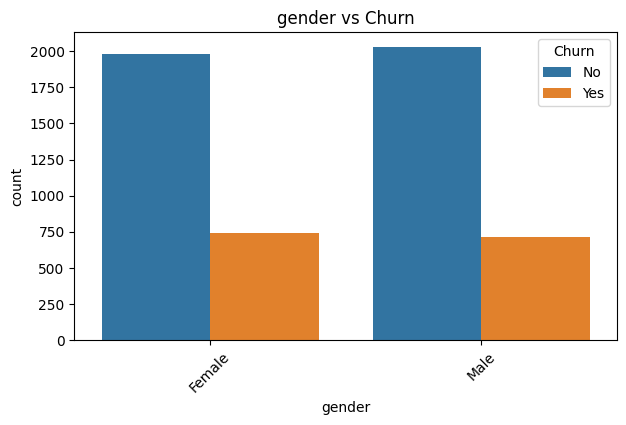

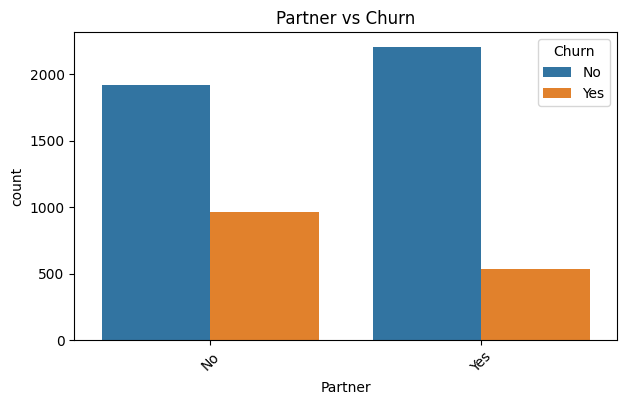

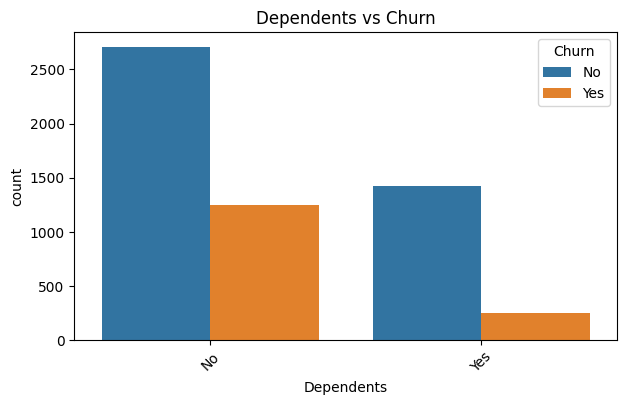

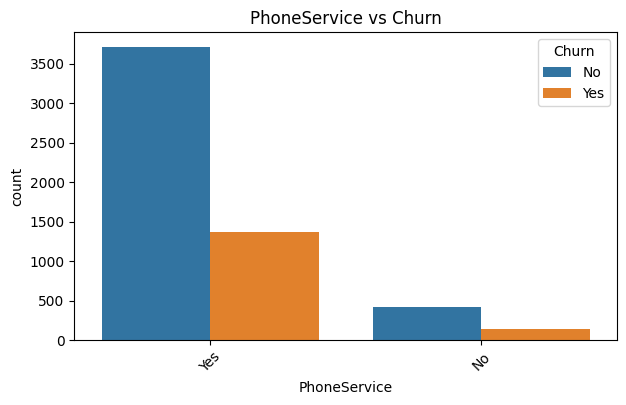

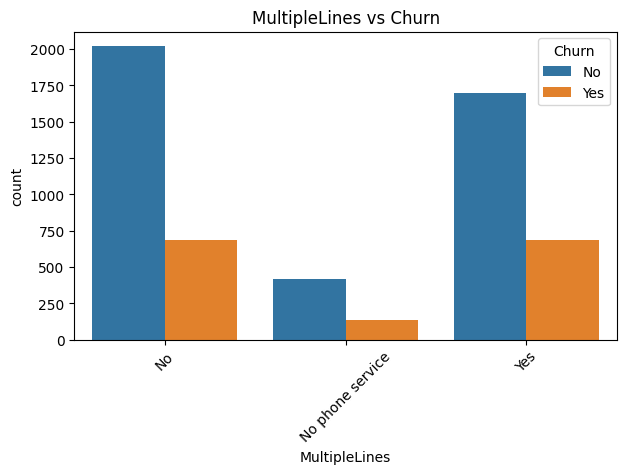

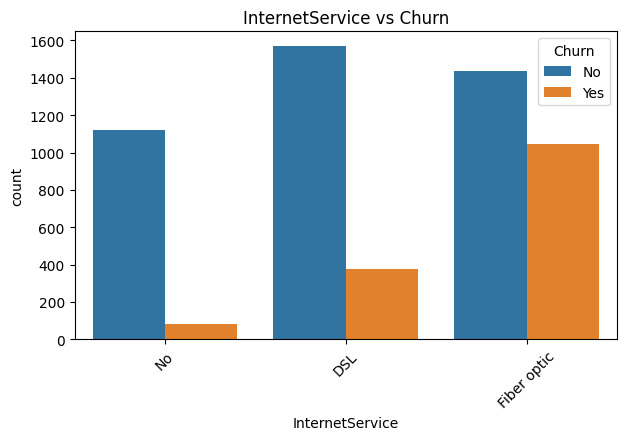

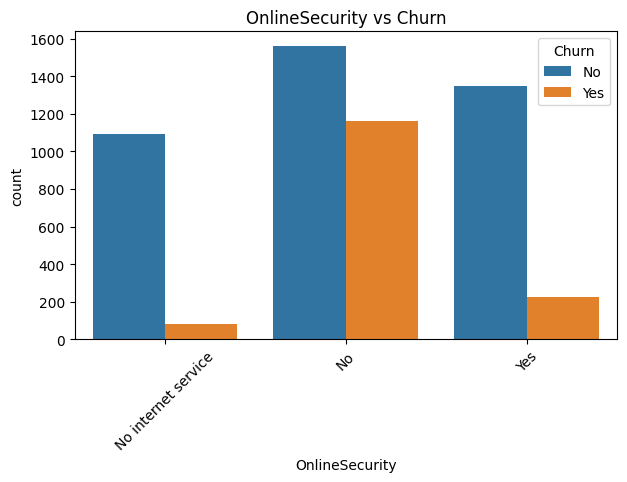

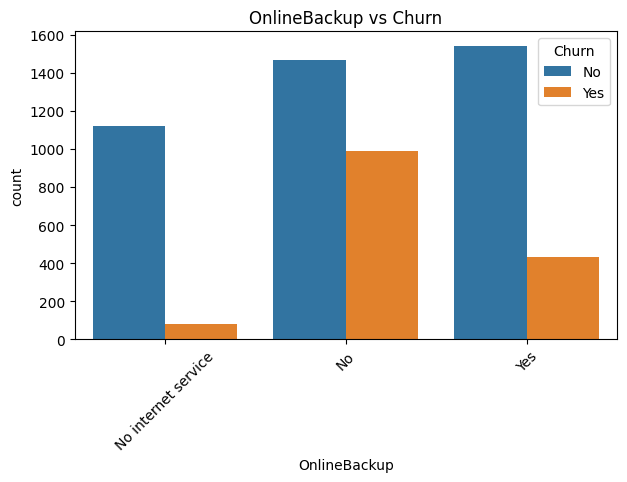

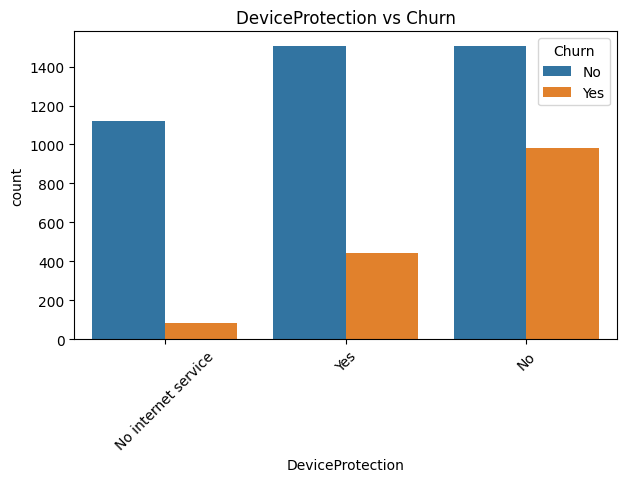

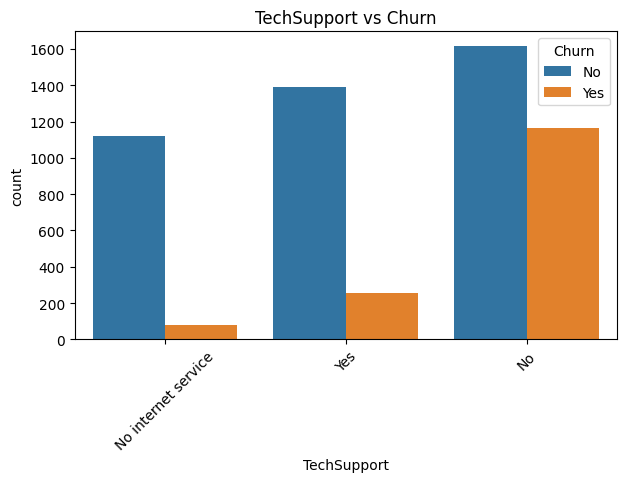

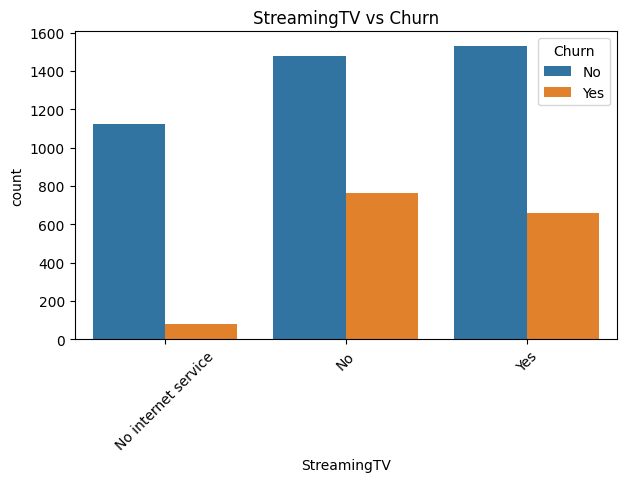

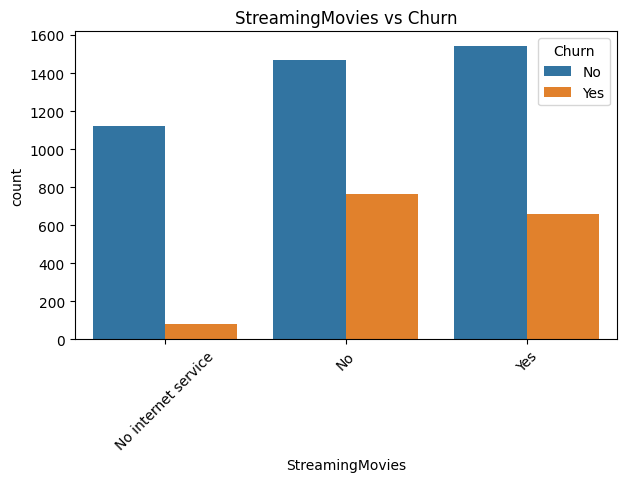

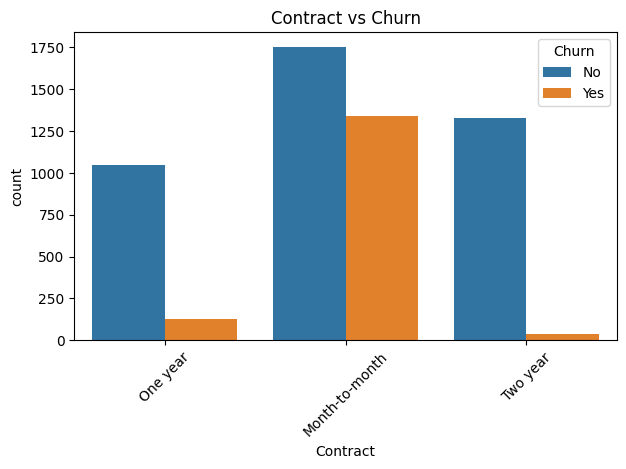

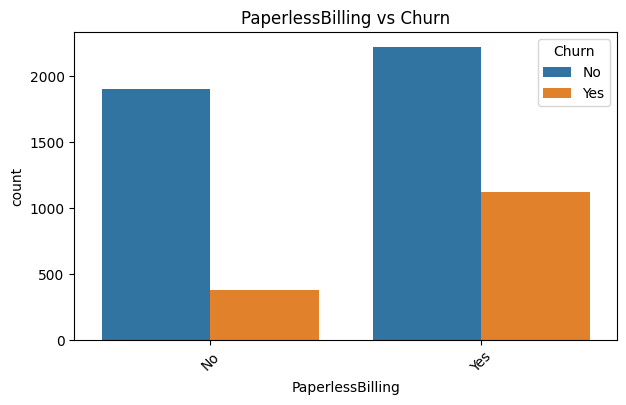

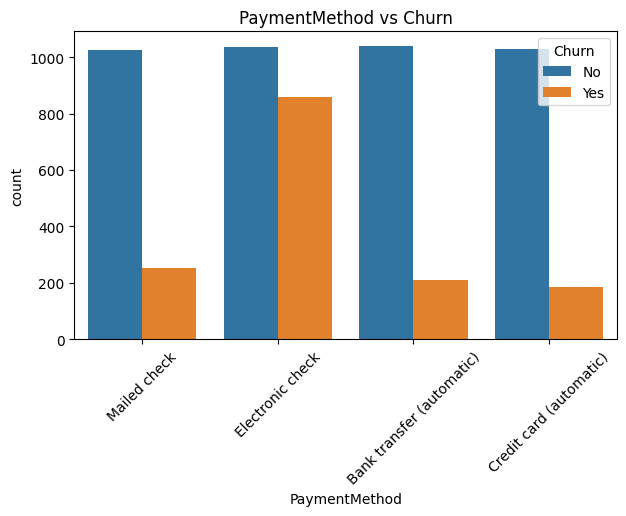

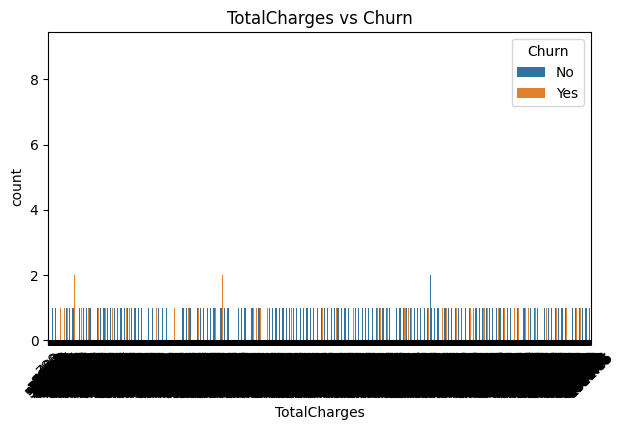

In [9]:
#relation with categorical features on churn
for col in categorical_cols:
    if col != 'Churn':
        plt.figure(figsize=(7,4))
        sns.countplot(x=col, hue='Churn', data=df)
        plt.xticks(rotation=45)
        plt.title(f'{col} vs Churn')
        plt.show()

In [10]:
df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


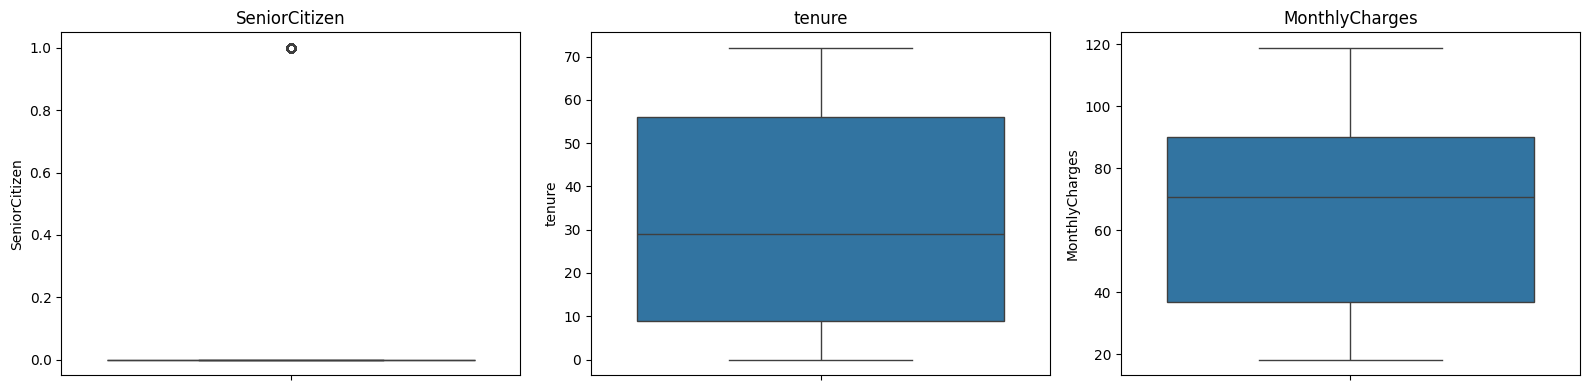

In [11]:
#outlier
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numerical_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

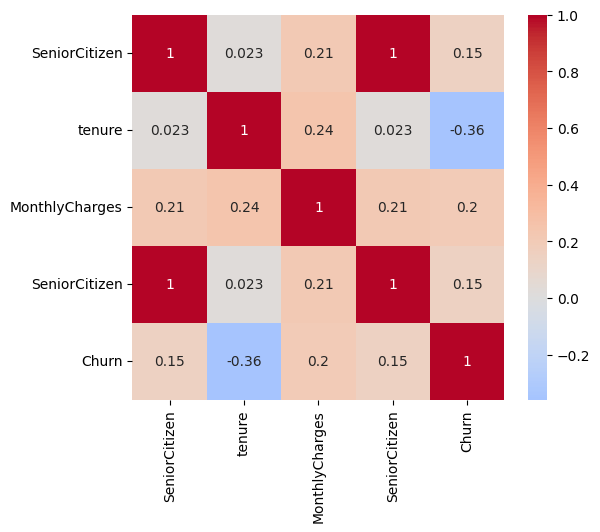

In [12]:
#correlation
corr_df = df.copy()
corr_df['Churn'] = (corr_df['Churn'] == 'Yes').astype(int)
corr = corr_df[numerical_cols.tolist() + ['SeniorCitizen', 'Churn']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

In [13]:
print("duplicate rows :",df.duplicated().sum())

duplicate rows : 0


**Data Preprocessing**

In [14]:
df=df.drop(columns=['customerID'])
df['TotalCharges'] =pd.to_numeric(df['TotalCharges'],errors='coerce')

In [15]:

df['MonthlyCharges'] = df['MonthlyCharges'].fillna(df['MonthlyCharges'].median())
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['OnlineSecurity'] = df['OnlineSecurity'].fillna(df['OnlineSecurity'].mode()[0])

In [16]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


**Feature Engineering**

In [17]:

df['CLV_Proxy'] = df['tenure'] * df['MonthlyCharges']
contract_weights = {'Month-to-month': 1, 'One year': 12, 'Two year': 24}
if 'Contract' in df.columns:
    df['Contract_Months'] = df['Contract'].map(contract_weights)
    df['Tenure_Contract_Interaction'] = df['tenure'] * df['Contract_Months']
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_1812/3280898647.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


In [18]:
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

In [19]:
df.tail()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,CLV_Proxy,Contract_Months,Tenure_Contract_Interaction,gender_Male,Partner_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5629,0,51,99.00,5038.15,0,5049.00,1,51,1,0,...,0,1,0,1,0,0,1,0,1,0
5630,1,68,41.95,2965.75,0,2852.60,24,1632,1,1,...,0,0,0,0,0,1,1,0,1,0
5631,0,72,19.95,1322.85,0,1436.40,24,1728,1,1,...,1,0,1,0,0,1,0,0,0,0
5632,0,69,82.45,5555.30,0,5689.05,24,1656,0,0,...,0,1,0,1,0,1,1,1,0,0
5633,1,22,63.55,1381.80,0,1398.10,1,22,1,1,...,0,0,0,0,0,0,1,0,0,1


In [20]:

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:

num_cols = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'CLV_Proxy', 'Contract_Months', 'Tenure_Contract_Interaction'
]
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [22]:
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,CLV_Proxy,Contract_Months,Tenure_Contract_Interaction,gender_Male,Partner_Yes,Dependents_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
4173,0,-0.997543,-0.769636,-0.853032,-0.870837,0.330467,-0.580409,1,1,1,...,0,0,0,0,1,0,1,0,0,1
5009,0,1.445099,-1.581011,-0.380961,-0.417846,1.588419,1.970849,0,0,0,...,1,0,1,0,0,1,0,0,0,0
2246,0,-0.956833,1.049023,-0.634562,-0.640952,-0.822656,-0.724913,1,0,0,...,0,1,0,1,0,0,1,0,0,0
481,0,0.834438,0.991811,1.197014,1.201761,0.330467,0.316518,1,1,0,...,0,1,0,1,1,0,1,0,0,0
1272,0,-0.712568,1.251867,-0.252902,-0.345224,-0.822656,-0.714948,0,1,0,...,0,1,0,1,0,0,0,0,1,0


**Model Development**

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       826
           1       0.65      0.58      0.61       301

    accuracy                           0.80      1127
   macro avg       0.75      0.73      0.74      1127
weighted avg       0.80      0.80      0.80      1127



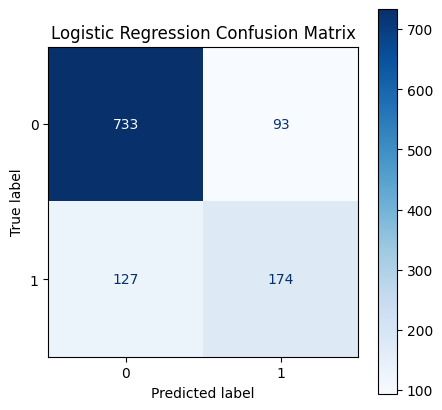

0.8047914818101154


In [23]:
log_model=LogisticRegression()
log_model.fit(X_train,y_train)
y_pred_lr=log_model.predict(X_test)

print(classification_report(y_test, y_pred_lr))
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

print(accuracy_score(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87       826
           1       0.65      0.58      0.61       301

    accuracy                           0.80      1127
   macro avg       0.75      0.73      0.74      1127
weighted avg       0.80      0.80      0.80      1127



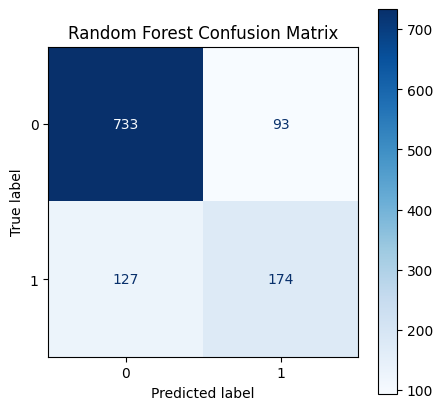

0.8047914818101154


In [24]:
rf_model=RandomForestClassifier()
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
print(classification_report(y_test, y_pred_lr))
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(log_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("Random Forest Confusion Matrix")
plt.show()

print(accuracy_score(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       826
           1       0.59      0.59      0.59       301

    accuracy                           0.78      1127
   macro avg       0.72      0.72      0.72      1127
weighted avg       0.78      0.78      0.78      1127



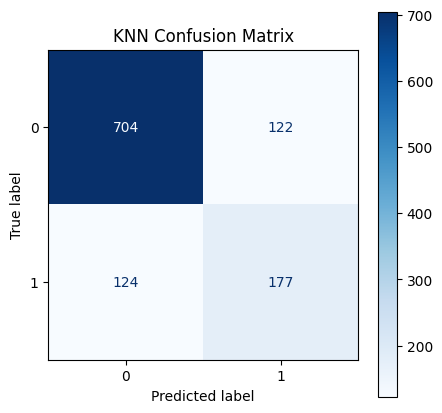

KNN Accuracy: 0.7817



In [25]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
print(classification_report(y_test, y_pred_knn))


fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_estimator(knn_model, X_test, y_test, cmap='Blues', ax=ax)
plt.title("KNN Confusion Matrix")
plt.show()
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}\n")

model evaluation

In [26]:
from sklearn.metrics import recall_score, precision_score, f1_score
models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn
}

summary_data = []
for name, preds in models.items():
    summary_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (Churn)': precision_score(y_test, preds),
        'Recall (Churn)': recall_score(y_test, preds),
        'F1-Score (Churn)': f1_score(y_test, preds)
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
0,Logistic Regression,0.804791,0.651685,0.578073,0.612676
1,Random Forest,0.804791,0.662651,0.548173,0.600000
2,KNN,0.781721,0.591973,0.588040,0.590000


### Final Model Selection

For a telecom company, correctly identifying customers who may leave is very important. Therefore, Recall is given more importance because failing to identify a potential customer who is likely to churn can result in a loss of revenue.

Among the models tested, Logistic Regression provided a good balance of Recall, Precision, and Accuracy. KNN also showed promising results. Therefore, Logistic Regression and KNN were selected for further hyperparameter tuning to see if their performance, especially Recall, could be improved.


**Hyper Parameter tuning(Logistic Regression)**

In [27]:
from sklearn.model_selection import GridSearchCV


log_param_grid = [
{
    'penalty':['l2'],
    'solver':['lbfgs','liblinear','newton-cg','sag','saga'],
    'C':[0.001,0.01,0.1,1,10,100],
    'class_weight':[None,'balanced'],
    'max_iter':[1000,2000,3000]
},
{
    'penalty':['l1'],
    'solver':['liblinear','saga'],
    'C':[0.001,0.01,0.1,1,10,100],
    'class_weight':[None,'balanced'],
    'max_iter':[1000,2000,3000]
}
]

grid_log = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=log_param_grid,
    scoring='accuracy',
    cv=10,
    n_jobs=-1
)

grid_log.fit(X_train, y_train)

print(f"Best Parameters found: {grid_log.best_params_}")
print(f"Best Cross-Validation Recall: {grid_log.best_score_:.4f}\n")


best_log_model = grid_log.best_estimator_
y_pred_tuned_lr = best_log_model.predict(X_test)

print("Tuned Logistic Regression Performance")
print(classification_report(y_test, y_pred_tuned_lr))
print(f"Tuned Accuracy: {accuracy_score(y_test, y_pred_tuned_lr):.4f}")

Best Parameters found: {'C': 10, 'class_weight': None, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'sag'}
Best Cross-Validation Recall: 0.7994

Tuned Logistic Regression Performance
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       826
           1       0.65      0.58      0.61       301

    accuracy                           0.80      1127
   macro avg       0.75      0.73      0.74      1127
weighted avg       0.80      0.80      0.80      1127

Tuned Accuracy: 0.8048


preprocesing the test data

In [28]:
df1=pd.read_csv('Testing_data.csv')
df1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [29]:
df1=df1.drop(columns=['customerID'])
df1['TotalCharges'] =pd.to_numeric(df1['TotalCharges'],errors='coerce')

In [30]:

df1['MonthlyCharges'] = df1['MonthlyCharges'].fillna(df1['MonthlyCharges'].median())
df1['TotalCharges'] = df1['TotalCharges'].fillna(df1['TotalCharges'].median())
df1['gender'] = df1['gender'].fillna(df1['gender'].mode()[0])
df1['OnlineSecurity'] = df1['OnlineSecurity'].fillna(df1['OnlineSecurity'].mode()[0])

In [31]:
df1.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [32]:

df1['CLV_Proxy'] = df1['tenure'] * df1['MonthlyCharges']
contract_weights = {'Month-to-month': 1, 'One year': 12, 'Two year': 24}
if 'Contract' in df1.columns:
    df1['Contract_Months'] = df1['Contract'].map(contract_weights)
    df1['Tenure_Contract_Interaction'] = df1['tenure'] * df1['Contract_Months']
df1['Churn'] = df1['Churn'].replace({'Yes': 1, 'No': 0})

/tmp/ipykernel_1812/3222774043.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['Churn'] = df1['Churn'].replace({'Yes': 1, 'No': 0})


In [33]:
categorical_cols = df1.select_dtypes(include=['object']).columns
df1 = pd.get_dummies(df1, columns=categorical_cols, drop_first=True, dtype=int)

In [34]:
df1.tail()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,CLV_Proxy,Contract_Months,Tenure_Contract_Interaction,gender_Male,Partner_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1404,0,27,55.45,1477.65,0,1497.15,12,324,1,0,...,0,0,0,0,1,0,0,0,0,0
1405,1,2,75.45,158.40,1,150.90,1,2,0,0,...,0,0,0,0,0,0,1,0,0,1
1406,0,3,75.15,216.75,1,225.45,1,3,0,1,...,0,0,0,0,0,0,1,1,0,0
1407,0,53,20.20,1068.15,0,1070.60,12,636,1,1,...,1,0,1,0,1,0,0,1,0,0
1408,0,64,73.55,4764.00,0,4707.20,1,64,1,1,...,0,0,0,0,0,0,1,0,0,1


In [35]:

X_final_test = df1.drop(columns=['Churn'])
y_final_test = df1['Churn']

num_cols1 = ['tenure', 'MonthlyCharges', 'TotalCharges', 'CLV_Proxy', 'Contract_Months', 'Tenure_Contract_Interaction']
X_final_test[num_cols1] = scaler.transform(X_final_test[num_cols1])
y_final_pred = best_log_model.predict(X_final_test)
print("Final Evaluation on Testing_data.csv:")
print(classification_report(y_final_test, y_final_pred))
print(f"Final Accuracy: {accuracy_score(y_final_test, y_final_pred):.4f}")

Final Evaluation on Testing_data.csv:
              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1044
           1       0.67      0.56      0.61       365

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409

Final Accuracy: 0.8141


## 1. Data & Preprocessing

**Dataset:** The dataset contains customer information related to demographics, services, and account details.

**Data Cleaning:** The `customerID` column was removed because it does not provide useful information for prediction. Missing values were handled using median and mode values, and categorical features were converted into numerical form using dummy variables with `pd.get_dummies`.

**Feature Engineering:** New features such as `CLV_Proxy` and `Tenure_Contract_Interaction` were created to better represent customer value, loyalty, and the effect of contract type.

## 2. Model Exploration & Tuning

**Model Selection:** Logistic Regression, Random Forest, and KNN were tested as the initial models. Logistic Regression performed well overall and had a competitive Recall, which is important for identifying customers who are likely to churn.

**Hyperparameter Tuning:** GridSearchCV with 10-fold cross-validation was used to find better parameters for the Logistic Regression model. The best parameters were `C=10`, `penalty='l2'`, and `solver='sag'`.

## 3. Final Performance

**Testing:** The optimized Logistic Regression model was tested on the separate `Testing_data.csv` dataset, which was not used during training.

**Final Result:** The model achieved a final accuracy of **81.83%** on the test dataset. This indicates that the model performs well on unseen customer data and can be useful for predicting customer churn.

